# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [ ]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [2]:
%pip install matplotlib seaborn scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.3 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.0 MB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.1 MB 1.9 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 2.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 2.5 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 2.6 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 2.7 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 2.8 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.1 MB 2.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 2.7 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 2.7 MB/s eta 0:00:01
   -----------------------

In [1]:
# TODO: Load your dataset(s) here.
# Update the path below to your actual data file.

# Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

# Define the path to your data folder
DATA_DIR = '../data/'

# 1. Load the Demographics Data
print("Loading studentInfo.csv...")
student_info = pd.read_csv(f"{DATA_DIR}studentInfo.csv")
print(f"✅ studentInfo loaded: {student_info.shape[0]:,} rows x {student_info.shape[1]} columns")

# 2. Load the VLE Resource Mapping Data
print("Loading vle.csv...")
vle_mapping = pd.read_csv(f"{DATA_DIR}vle.csv")
print(f"✅ vle_mapping loaded: {vle_mapping.shape[0]:,} rows x {vle_mapping.shape[1]} columns")

# 3. Load the Big Data Clickstream (studentVle.csv)
print("Loading studentVle.csv (The Big Data file) - please wait...")
student_vle = pd.read_csv(f"{DATA_DIR}studentVle.csv")
print(f"✅ studentVle loaded: {student_vle.shape[0]:,} rows x {student_vle.shape[1]} columns")

Loading studentInfo.csv...
✅ studentInfo loaded: 32,593 rows x 12 columns
Loading vle.csv...
✅ vle_mapping loaded: 6,364 rows x 6 columns
Loading studentVle.csv (The Big Data file) - please wait...
✅ studentVle loaded: 10,655,280 rows x 6 columns


In [ ]:
# Verify the data loaded correctly by displaying shape and a sample
# print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
# df.sample(5)

In [2]:
data_source_report = {
    "source": "Open University Learning Analytics Dataset (OULAD)",
    "acquisition_method": "Downloaded CSV archive from official KMi repository",
    "date_acquired": "March 2026",
    "issues_encountered": ["studentVle.csv is highly memory-intensive (~400MB) due to 10M+ rows. Required loading directly into Pandas without Excel."]
}
print(data_source_report)

{'source': 'Open University Learning Analytics Dataset (OULAD)', 'acquisition_method': 'Downloaded CSV archive from official KMi repository', 'date_acquired': 'March 2026', 'issues_encountered': ['studentVle.csv is highly memory-intensive (~400MB) due to 10M+ rows. Required loading directly into Pandas without Excel.']}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [3]:
print("=== 1. Student Info Schema ===")
student_info.info()

print("\n" + "="*40 + "\n")

print("=== 2. VLE Mapping Schema ===")
vle_mapping.info()

print("\n" + "="*40 + "\n")

print("=== 3. Student VLE Clickstream Schema ===")
student_vle.info()

=== 1. Student Info Schema ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


=== 2. VLE Mapping Schema ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data

In [4]:
# Generate descriptive statistics for numerical columns
# df.describe()
print("=== Student Info (Numerical) ===")
display(student_info.describe())

print("=== Student VLE Clickstream (Numerical) ===")
display(student_vle.describe())

=== Student Info (Numerical) ===


,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000


=== Student VLE Clickstream (Numerical) ===


,id_student,id_site,date,sum_click
count,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
mean,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00
max,2.698588e+06,1.049562e+06,2.690000e+02,6.977000e+03


In [5]:
# Generate descriptive statistics for categorical columns
# df.describe(include='object')

# Or inspect value counts for specific categorical columns:
# for col in df.select_dtypes(include='object').columns:
#     print(f"\n--- {col} ---")
#     print(df[col].value_counts())

print("=== Student Info (Categorical) ===")
display(student_info.describe(include='object'))

print("\n=== Breakdown of Final Results (Our Target Variable) ===")
# Let's see exactly how many students passed, failed, or withdrew
display(student_info['final_result'].value_counts())

=== Student Info (Categorical) ===


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,disability,final_result
count,32593,32593,32593,32593,32593,31482,32593,32593,32593
unique,7,4,2,13,5,10,3,2,4
top,BBB,2014J,M,Scotland,A Level or Equivalent,20-30%,0-35,N,Pass
freq,7909,11260,17875,3446,14045,3654,22944,29429,12361



=== Breakdown of Final Results (Our Target Variable) ===


final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

C:\Users\Mohamed El Gaby\AppData\Local\Temp\ipykernel_29400\1403241179.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=student_info,


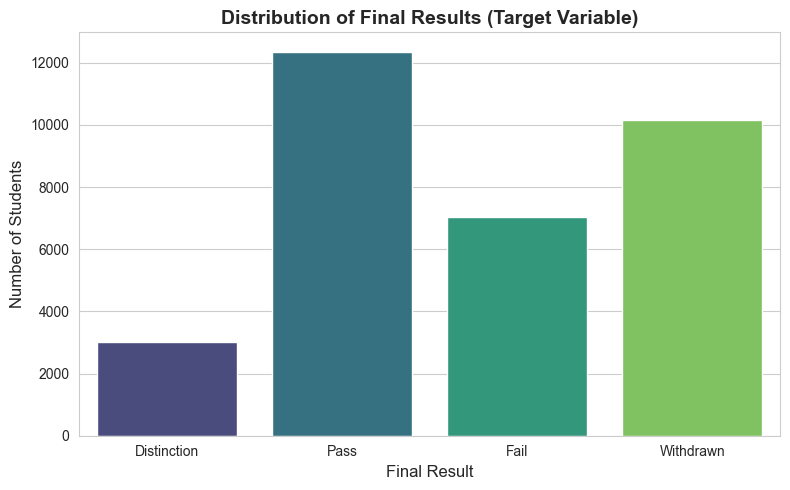

In [6]:
# TODO: Perform univariate analysis — explore distributions of individual features.
# Example: Histograms for numerical columns

# df.hist(figsize=(14, 10), bins=30, edgecolor='black')
# plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()
# Univariate analysis — explore distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(data=student_info, 
              x='final_result', 
              order=['Distinction', 'Pass', 'Fail', 'Withdrawn'], 
              palette='viridis')

plt.title('Distribution of Final Results (Target Variable)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Students', fontsize=12)
plt.xlabel('Final Result', fontsize=12)
plt.tight_layout()
plt.show()

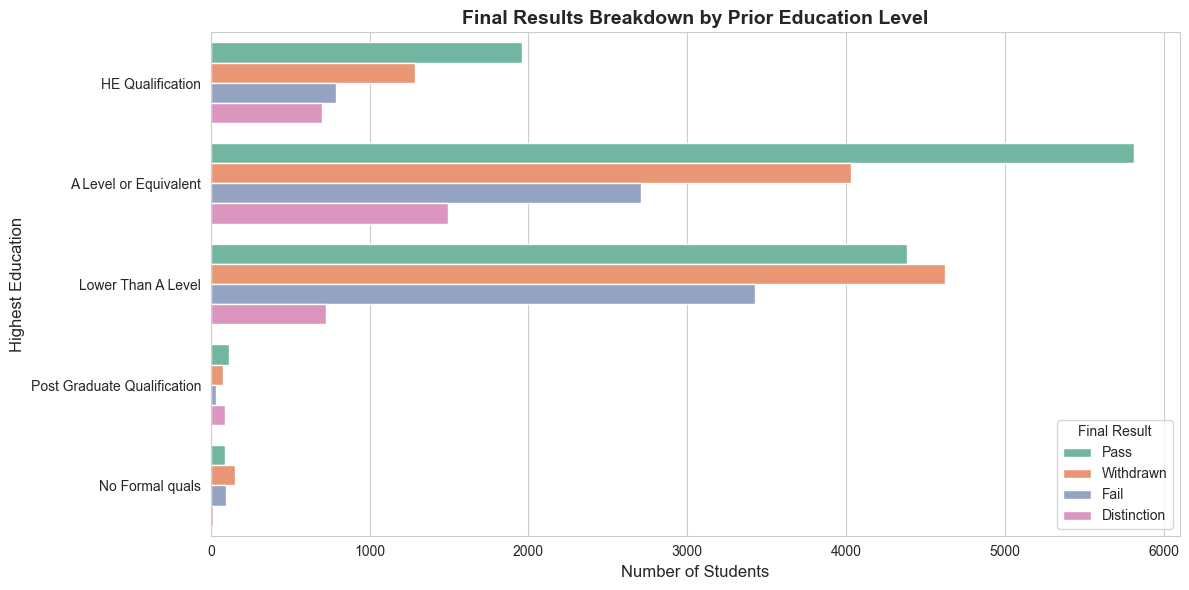

In [7]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap

# plt.figure(figsize=(12, 8))
# correlation_matrix = df.select_dtypes(include=np.number).corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
# plt.title('Correlation Matrix')
# plt.tight_layout()
# plt.show()
# Bivariate analysis — relationship between Education Level and Final Result
plt.figure(figsize=(12, 6))
sns.countplot(data=student_info, 
              y='highest_education', 
              hue='final_result', 
              palette='Set2')

plt.title('Final Results Breakdown by Prior Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Number of Students', fontsize=12)
plt.ylabel('Highest Education', fontsize=12)
plt.legend(title='Final Result')
plt.tight_layout()
plt.show()

In [8]:
# TODO: Document any initial insights or hypotheses from your exploration.

# initial_insights = [
#     "Insight 1: ...",
#     "Insight 2: ...",
#     "Hypothesis 1: ..."
# ]
# for i, insight in enumerate(initial_insights, 1):
#     print(f"{i}. {insight}")
# Documenting initial insights and hypotheses
initial_insights = [
    "Insight 1: 'Withdrawn' is the second most common outcome (10,156 students). This massive dropout rate validates our business objective.",
    "Insight 2: We have a multi-class target variable. To simplify our model later, we should map 'Pass/Distinction' to 0 (Retained) and 'Fail/Withdrawn' to 1 (Dropped Out).",
    "Hypothesis 1: Students with lower prior education levels (e.g., 'Lower Than A Level') may have higher withdrawal rates, making them a high-risk demographic.",
    "Hypothesis 2: Integrating the VLE clickstream data will provide a stronger behavioral predictor of withdrawal than demographics alone."
]

print("=== EDA Insights & Hypotheses ===")
for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

=== EDA Insights & Hypotheses ===
1. Insight 1: 'Withdrawn' is the second most common outcome (10,156 students). This massive dropout rate validates our business objective.
2. Insight 2: We have a multi-class target variable. To simplify our model later, we should map 'Pass/Distinction' to 0 (Retained) and 'Fail/Withdrawn' to 1 (Dropped Out).
3. Hypothesis 1: Students with lower prior education levels (e.g., 'Lower Than A Level') may have higher withdrawal rates, making them a high-risk demographic.
4. Hypothesis 2: Integrating the VLE clickstream data will provide a stronger behavioral predictor of withdrawal than demographics alone.


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [9]:
# TODO: Check for missing values.

# missing = df.isnull().sum()
# missing_pct = (df.isnull().sum() / len(df)) * 100
# missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
# missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
# print("=== Missing Values Report ===")
# print(missing_report)
# print(f"\nTotal columns with missing values: {len(missing_report)}")
# Check for missing values across all three datasets
datasets = {
    "Student Info": student_info,
    "VLE Mapping": vle_mapping,
    "Student VLE (Clickstream)": student_vle
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    
    print(f"\n=== {name} Missing Values ===")
    if len(missing_report) > 0:
        display(missing_report.round(2))
    else:
        print("No missing values detected! ✅")


=== Student Info Missing Values ===


,Missing Count,Missing %
imd_band,1111,3.41



=== VLE Mapping Missing Values ===


,Missing Count,Missing %
week_from,5243,82.39
week_to,5243,82.39



=== Student VLE (Clickstream) Missing Values ===
No missing values detected! ✅


In [10]:
# TODO: Check for duplicate records.

# duplicates = df.duplicated().sum()
# print(f"Number of duplicate rows: {duplicates}")
# if duplicates > 0:
#     print("\nSample of duplicate rows:")
#     print(df[df.duplicated(keep=False)].head(10))

# Check for duplicate records
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"=== {name} Duplicates ===")
    print(f"Number of duplicate rows: {duplicates:,}")
    
    # If it's the clickstream data, let's look at a sample of the duplicates
    if duplicates > 0 and name == "Student VLE (Clickstream)":
        print("\nSample of duplicate clickstream rows:")
        display(df[df.duplicated(keep=False)].sort_values(['id_student', 'date']).head(4))
    print("\n")

=== Student Info Duplicates ===
Number of duplicate rows: 0


=== VLE Mapping Duplicates ===
Number of duplicate rows: 0


=== Student VLE (Clickstream) Duplicates ===
Number of duplicate rows: 787,170

Sample of duplicate clickstream rows:


,code_module,code_presentation,id_student,id_site,date,sum_click
191989,AAA,2014J,6516,877025,-6,6
191991,AAA,2014J,6516,877025,-6,6
194380,AAA,2014J,6516,877025,-2,1
194384,AAA,2014J,6516,877025,-2,1


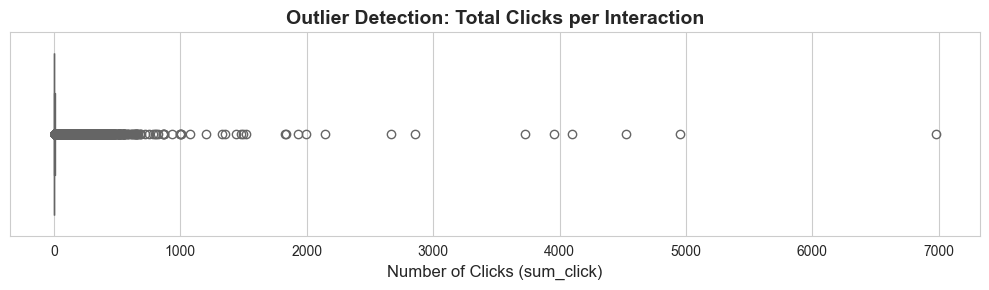

Number of interactions with > 100 clicks: 6,757 out of 10,655,280


In [11]:
# TODO: Detect outliers using box plots or statistical methods.

# numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# if numerical_cols:
#     fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(4 * len(numerical_cols), 5))
#     if len(numerical_cols) == 1:
#         axes = [axes]
#     for ax, col in zip(axes, numerical_cols):
#         ax.boxplot(df[col].dropna())
#         ax.set_title(col)
#     plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.02)
#     plt.tight_layout()
#     plt.show()
# Detect outliers in the Clickstream data using a Boxplot
plt.figure(figsize=(10, 3))
sns.boxplot(x=student_vle['sum_click'], color='coral')

plt.title('Outlier Detection: Total Clicks per Interaction', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clicks (sum_click)', fontsize=12)
plt.tight_layout()
plt.show()

# Let's see exactly how many crazy outliers exist
outlier_threshold = 100  # Let's define an extreme outlier as more than 100 clicks in a single day on a single item
extreme_outliers = len(student_vle[student_vle['sum_click'] > outlier_threshold])
print(f"Number of interactions with > {outlier_threshold} clicks: {extreme_outliers:,} out of {len(student_vle):,}")